# Filtragem de marés utilizando o filtro Butteworth e posterior reamostragem

### Demonstração passo a passo

###### Importação do dado

In [1]:
import pandas as pd

root = r"C:\DCPS\Projetos\mare_dora\mares_   43_ 199.txt"
dado = pd.read_csv(root,delim_whitespace=True,names=['data','hora','h'])
# Ajeitando tabulação. Quero uma coluna somente para representar todas as datas.
dado['data'] = dado['data']+' '+dado['hora']
del dado['hora']
# Convertendo vetor de datas de string para datetime.
dado['data'] = pd.to_datetime(dado['data'])

dado.head()

,data,h
0,2021-10-05 00:00:00,3.103
1,2021-10-05 00:01:00,3.101
2,2021-10-05 00:02:00,3.123
3,2021-10-05 00:03:00,3.136
4,2021-10-05 00:04:00,3.139


###### Aplicação do Butteworth Filter

In [2]:
from scipy import signal

fs = 1000  # Sampling frequency
fc = 30  # Cut-off frequency of the filter
w = fc / (fs / 2) # Normalize the frequency
b, a = signal.butter(5, w, 'low')
output = signal.filtfilt(b, a, dado.h)

# Criando pandas DataFrame do dado filtrado
filtrado = dado.copy()
filtrado['h'] = output

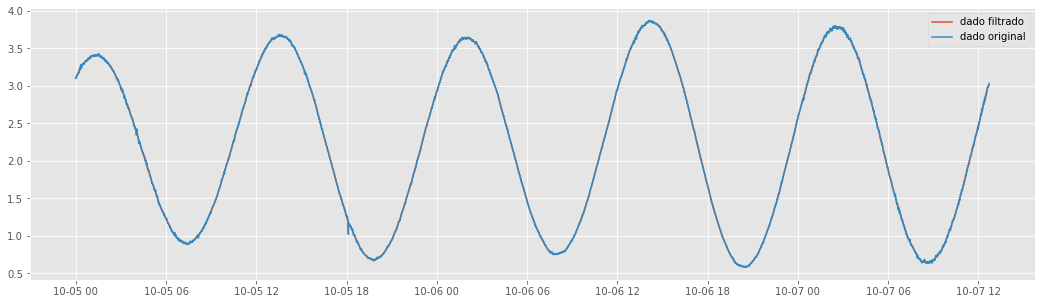

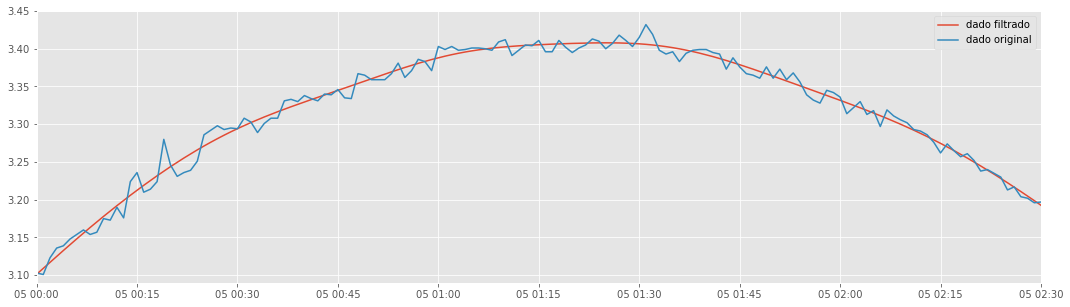

In [3]:
import matplotlib.pyplot as plt
plt.style.use('ggplot') 

# Série completa
plt.figure(figsize=(18,5))
plt.plot(filtrado.data,filtrado.h, label='dado filtrado')
plt.plot(dado.data,dado.h, label='dado original')
plt.legend()
plt.show()

# Série reduzida para facilitar visualização do filtro
plt.figure(figsize=(18,5))
plt.plot(filtrado.data,filtrado.h, label='dado filtrado')
plt.plot(dado.data,dado.h, label='dado original')
plt.legend()
plt.xlim(dado.data[0],dado.data[150])
plt.ylim(3.09,3.45)
plt.show()

###### Reamostragem

In [4]:
print("O intervalo de amostragem é:")
print(dado.data[1] - dado.data[0])

# Intervalo de 1 minuto

O intervalo de amostragem é:
0 days 00:01:00


In [5]:
# Criando pandas DataFrame reamostrando de 6 em 6 minutos, a partir da matriz filtrada.
reamostrado = filtrado.iloc[::6].reset_index(drop=True)
reamostrado.head()

,data,h
0,2021-10-05 00:00:00,3.101245
1,2021-10-05 00:06:00,3.148197
2,2021-10-05 00:12:00,3.192161
3,2021-10-05 00:18:00,3.231750
4,2021-10-05 00:24:00,3.266037


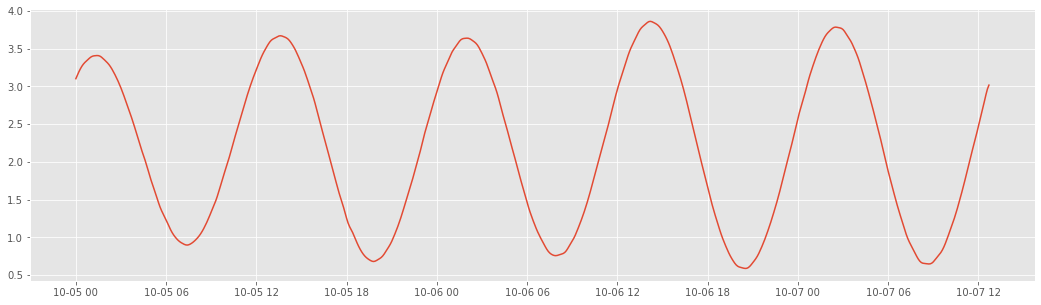

In [6]:
plt.figure(figsize=(18,5))
plt.plot(reamostrado.data,reamostrado.h)
plt.show()

###### Output

In [7]:
reamostrado.to_csv(r"C:\DCPS\Projetos\mare_dora\mare_filtrada_reamostrada.txt", index=False, header=True)

### Criação de função para facilitar posterior uso

A função considera que os dados de input são sempre de minuto em minuto. Caso o timedelta seja diferente de 1 minuto, posso melhorar a função considerando essa variável. Do contrario, é isso!

In [8]:
def BW_reamostra_mare(root_input, fator_de_reamostragem):
    
    
    # Importação do dado e condicionamento em formato conveniente.
    import pandas as pd
    dado = pd.read_csv(root,delim_whitespace=True,names=['data','hora','h'])
    # Ajeitando tabulação. Quero uma coluna somente para representar todas as datas.
    dado['data'] = dado['data']+' '+dado['hora']
    del dado['hora']
    # Convertendo vetor de datas de string para datetime.
    dado['data'] = pd.to_datetime(dado['data'])
    
    # Filtro Butteworth.
    from scipy import signal
    fs = 1000  # Sampling frequency.
    fc = 30  # Cut-off frequency of the filter.
    w = fc / (fs / 2) # Normalize the frequency.
    b, a = signal.butter(5, w, 'low')
    output = signal.filtfilt(b, a, dado.h)
    # Criando pandas DataFrame do dado filtrado.
    filtrado = dado.copy()
    filtrado['h'] = output
    
    # Reamostragem a partir do dado já filtrado.
    reamostrado = filtrado.iloc[::fator_de_reamostragem].reset_index(drop=True)
    
    return reamostrado

###### Teste

                 data         h
0 2021-10-05 00:00:00  3.101245
1 2021-10-05 00:06:00  3.148197
2 2021-10-05 00:12:00  3.192161
3 2021-10-05 00:18:00  3.231750
4 2021-10-05 00:24:00  3.266037


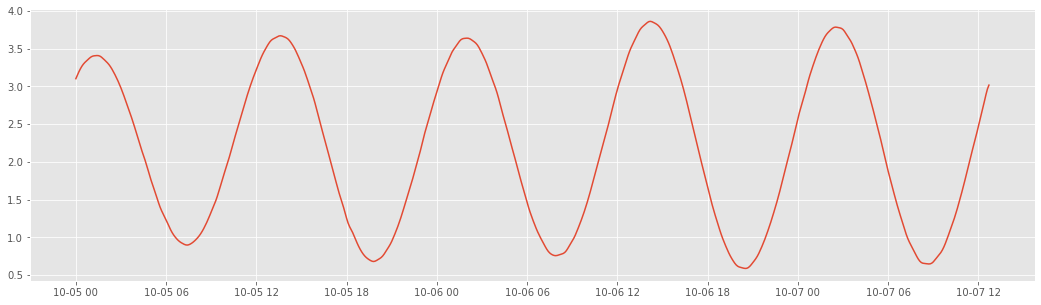

In [9]:
# Especificando variáveis.
root_input = r"C:\DCPS\Projetos\mare_dora\mares_   43_ 199.txt"
fator_de_reamostragem = 6

# Chamando a função criada.
novo_dado = BW_reamostra_mare(root_input, fator_de_reamostragem)
print(novo_dado.head())

# Salvando a nova matriz de dados como arquivo texto
novo_dado.to_csv(r"C:\DCPS\Projetos\mare_dora\mare_filtrada_reamostrada.txt", index=False, header=True)

# Plotando novo dado para testar.
plt.figure(figsize=(18,5))
plt.plot(novo_dado.data,novo_dado.h)
plt.show()